In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import squarify

import warnings
warnings.filterwarnings('ignore')
from core.data import load_from_kaggle


In [2]:
dataset_link = "kanchana1990/bacteria-dataset" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\bacteria-dataset' already exists with files. Skipping download (replace=False).


In [3]:
files

['bacteria_list_200.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,Name,Family,Where Found,Harmful to Humans
0,Escherichia coli,Enterobacteriaceae,Intestinal tract,Yes
1,Staphylococcus aureus,Staphylococcaceae,"Skin, nasal passages",Yes
2,Lactobacillus acidophilus,Lactobacillaceae,Human mouth & intestine,No
3,Bacillus subtilis,Bacillaceae,Soil,No
4,Clostridium botulinum,Clostridiaceae,"Soil, improperly canned foods",Yes


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(199, 4)

'Description'

,count,unique,top,freq
Name,199,194,Coxiella burnetii,2
Family,199,93,Enterobacteriaceae,21
Where Found,199,120,Soil,17
Harmful to Humans,199,3,No,102


'Duplicates'

np.int64(3)

,Data Types,Missing Values,Unique Values,Sample Values
Name,object,0,194,"[Facklamia hominis, Gallionella ferruginea, Bd..."
Family,object,0,93,"[Pasteurellaceae, Nocardiopsaceae, Leuconostoc..."
Where Found,object,0,120,"[Human intestine, Symbiotic with nematodes, Ho..."
Harmful to Humans,object,0,3,"[No, Yes, No]"


In [6]:
#search for unique values
for col in df.columns:
    print('name', col)
    print('\n')
    print(df[col].unique())
    print('\n'*2)

name Name


['Escherichia coli' 'Staphylococcus aureus' 'Lactobacillus acidophilus'
 'Bacillus subtilis' 'Clostridium botulinum' 'Streptococcus pneumoniae'
 'Pseudomonas aeruginosa' 'Mycobacterium tuberculosis' 'Vibrio cholerae'
 'Salmonella enterica' 'Helicobacter pylori' 'Neisseria gonorrhoeae'
 'Lactococcus lactis' 'Bacteroides fragilis' 'Campylobacter jejuni'
 'Listeria monocytogenes' 'Acetobacter aceti' 'Streptococcus mutans'
 'Propionibacterium acnes' 'Bifidobacterium bifidum'
 'Clostridium difficile' 'Legionella pneumophila' 'Borrelia burgdorferi'
 'Treponema pallidum' 'Chlamydia trachomatis' 'Mycoplasma pneumoniae'
 'Streptococcus pyogenes' 'Haemophilus influenzae'
 'Leptospira interrogans' 'Streptococcus agalactiae'
 'Shigella dysenteriae' 'Enterococcus faecalis'
 'Corynebacterium diphtheriae' 'Klebsiella pneumoniae'
 'Rickettsia rickettsii' 'Serratia marcescens' 'Proteus mirabilis'
 'Gardnerella vaginalis' 'Francisella tularensis' 'Yersinia pestis'
 'Clostridium perfringens' 

In [7]:
df['Harmful to Humans'].value_counts()

Harmful to Humans
No      102
Yes      96
 Yes      1
Name: count, dtype: int64

In [8]:
#correction of typing mistake
df['Harmful to Humans'] = df['Harmful to Humans'].replace({' Yes':'Yes'})
df['Harmful to Humans'].unique()

array(['Yes', 'No'], dtype=object)

In [9]:
#deal with duplicates
df[df.duplicated(keep=False)]

,Name,Family,Where Found,Harmful to Humans
37,Gardnerella vaginalis,Bifidobacteriaceae,Genitourinary tract,Yes
38,Francisella tularensis,Francisellaceae,"Infected animals, water",Yes
45,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
55,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
58,Francisella tularensis,Francisellaceae,"Infected animals, water",Yes
59,Gardnerella vaginalis,Bifidobacteriaceae,Genitourinary tract,Yes


In [10]:
#delete duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

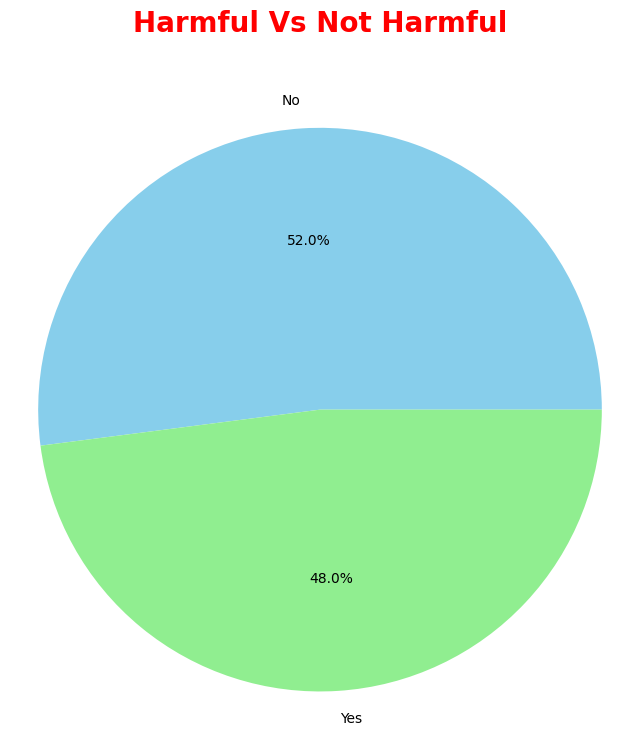

In [11]:
#percentage of harmful and not harmful bacteria in data
harmful_count = df["Harmful to Humans"].value_counts()

plt.figure(figsize = (8, 8))
plt.pie(harmful_count, labels = harmful_count.index, autopct = "%1.1f%%", colors = ["skyblue", "lightgreen"])
plt.title("Harmful Vs Not Harmful", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.axis("equal")
plt.show()

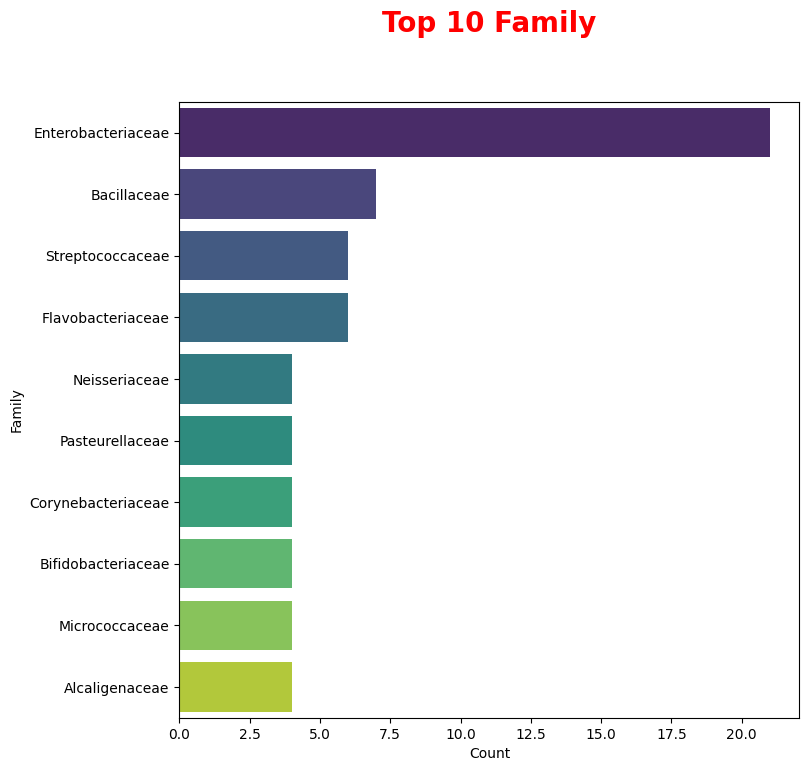

In [12]:
# top 10 families in data
family_counts = df["Family"].value_counts().head(10)

plt.figure(figsize = (8, 8))
sns.barplot(x = family_counts, y = family_counts.index, palette = "viridis")
plt.title("Top 10 Family", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.xlabel("Count")
plt.ylabel("Family")
plt.show()

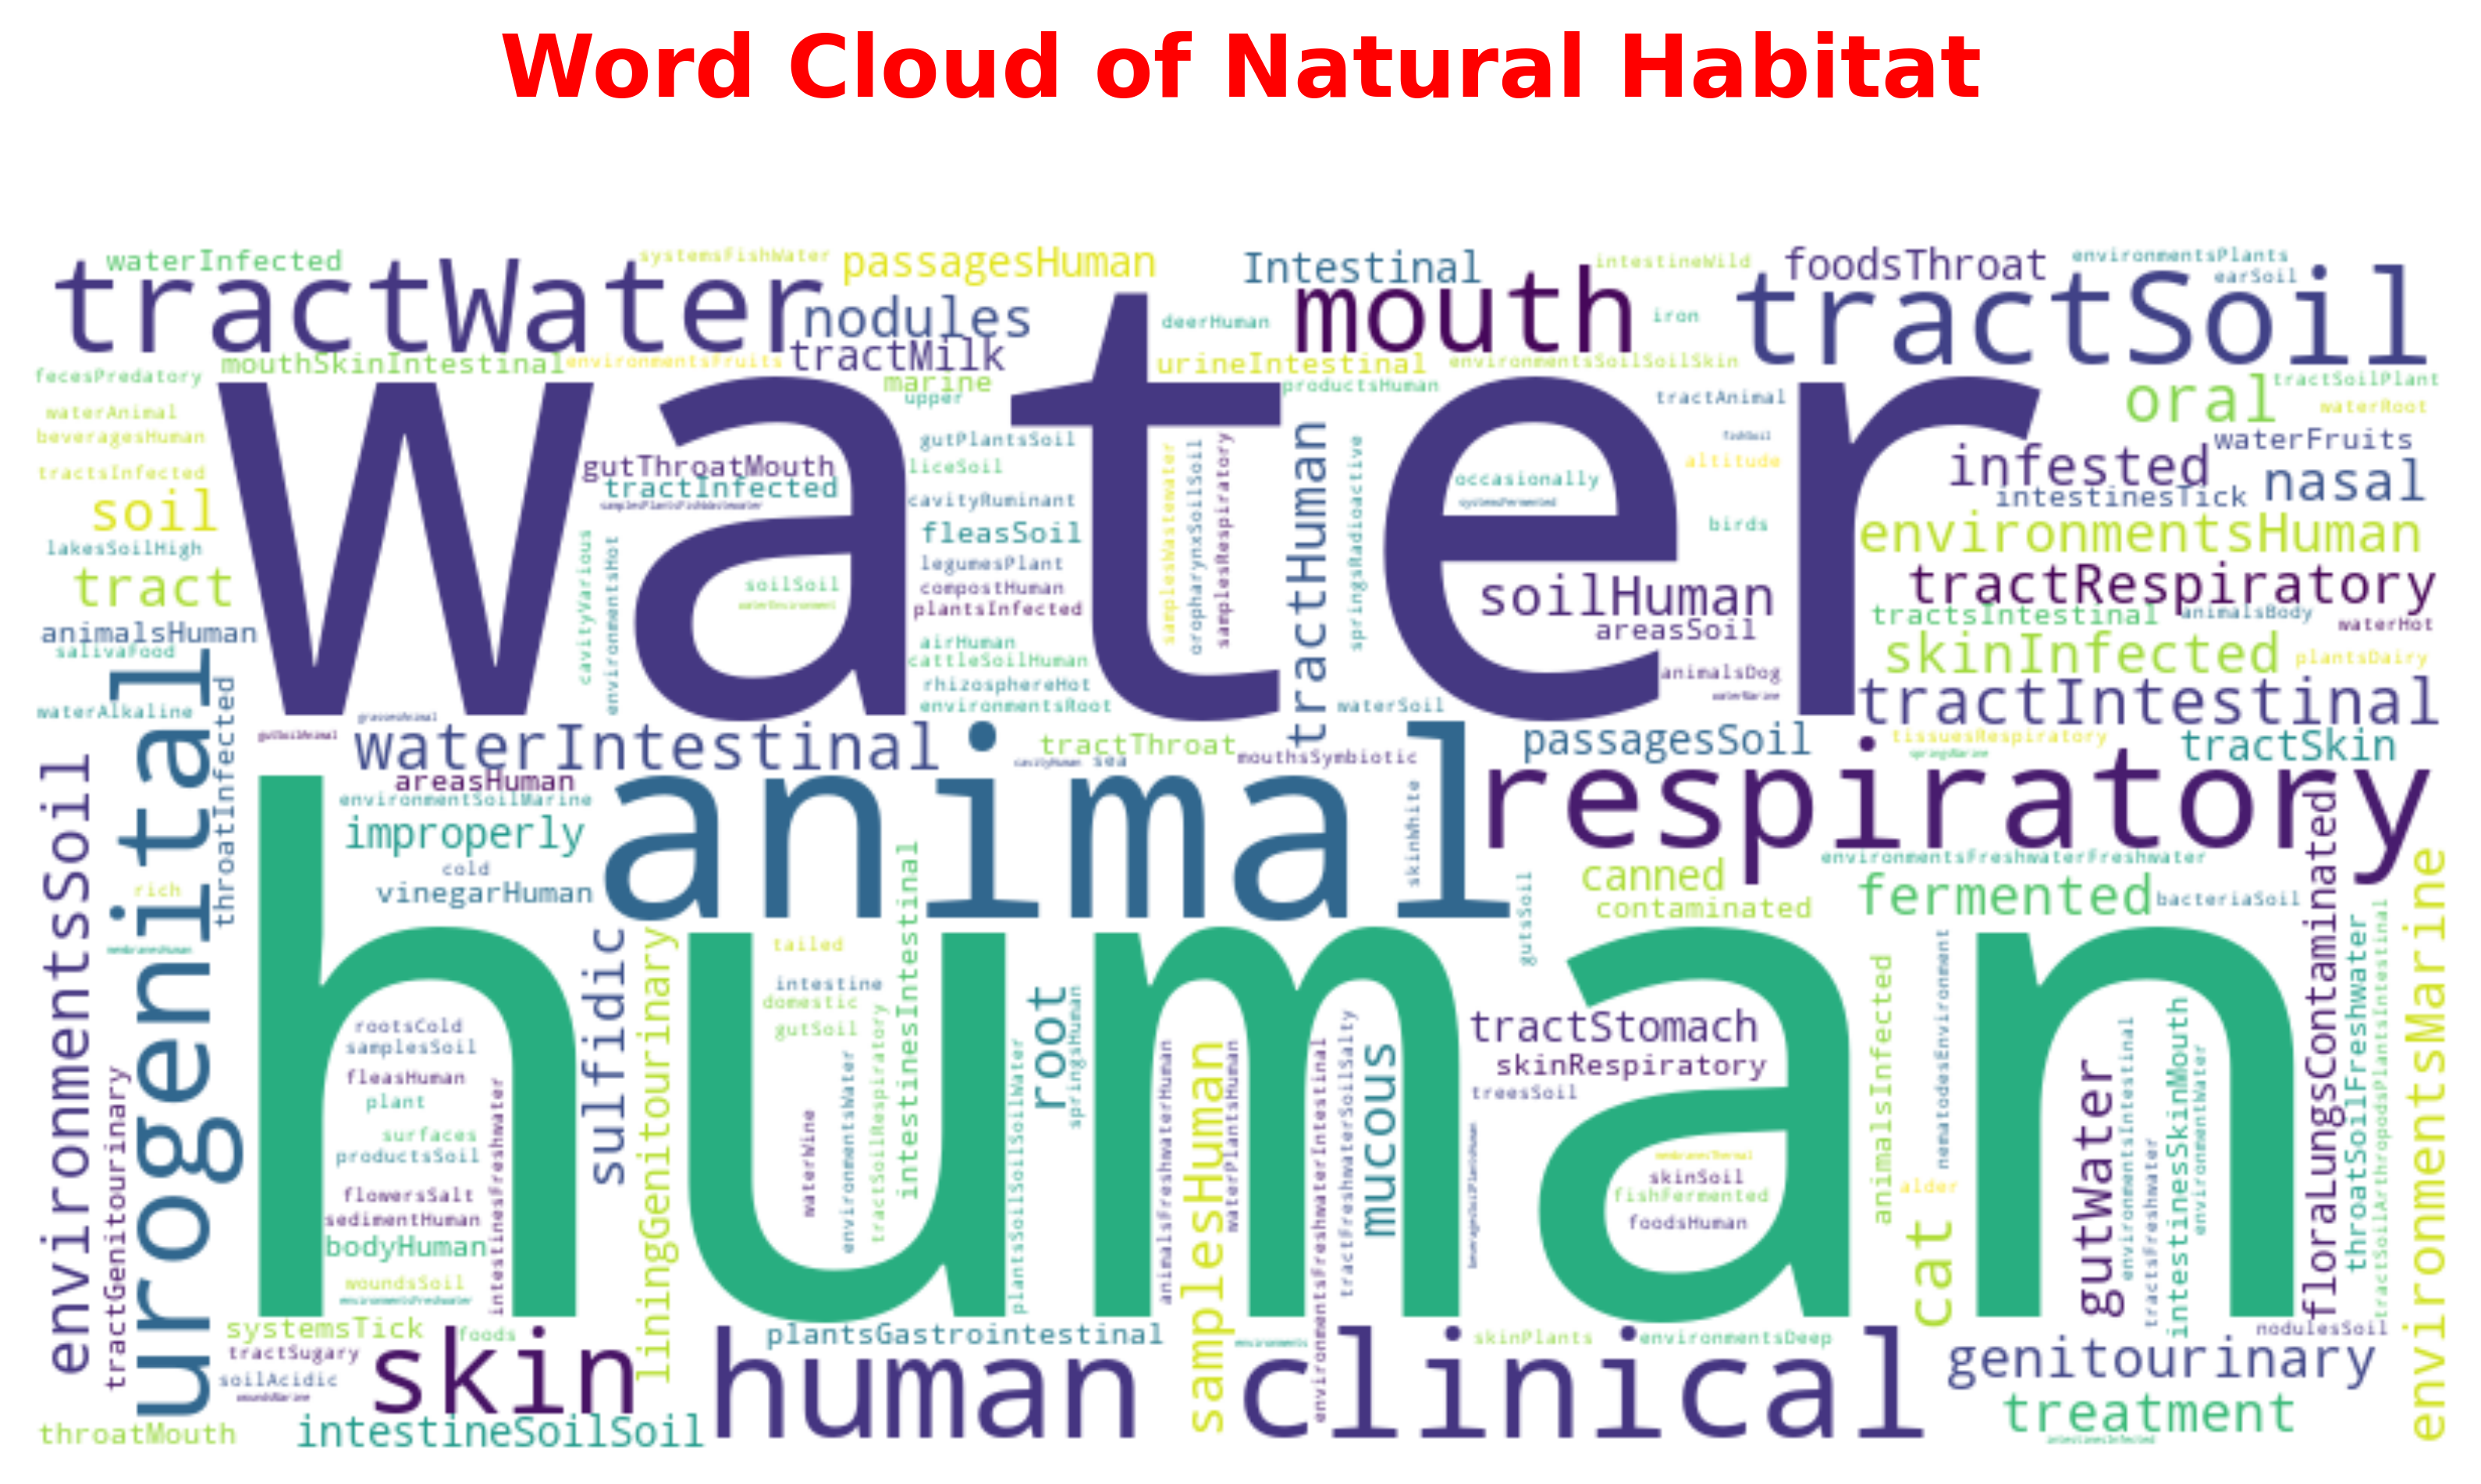

In [13]:
#Combine all Natural habitats into single string

habitat_text = "".join(df["Where Found"])

# Generate  a word cloud image

wordcloud = WordCloud(width = 800, height = 400, background_color = "white").generate(habitat_text)

# Plot the word cloud

plt.figure(figsize = (10, 6), dpi=400)
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Word Cloud of Natural Habitat", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.show()


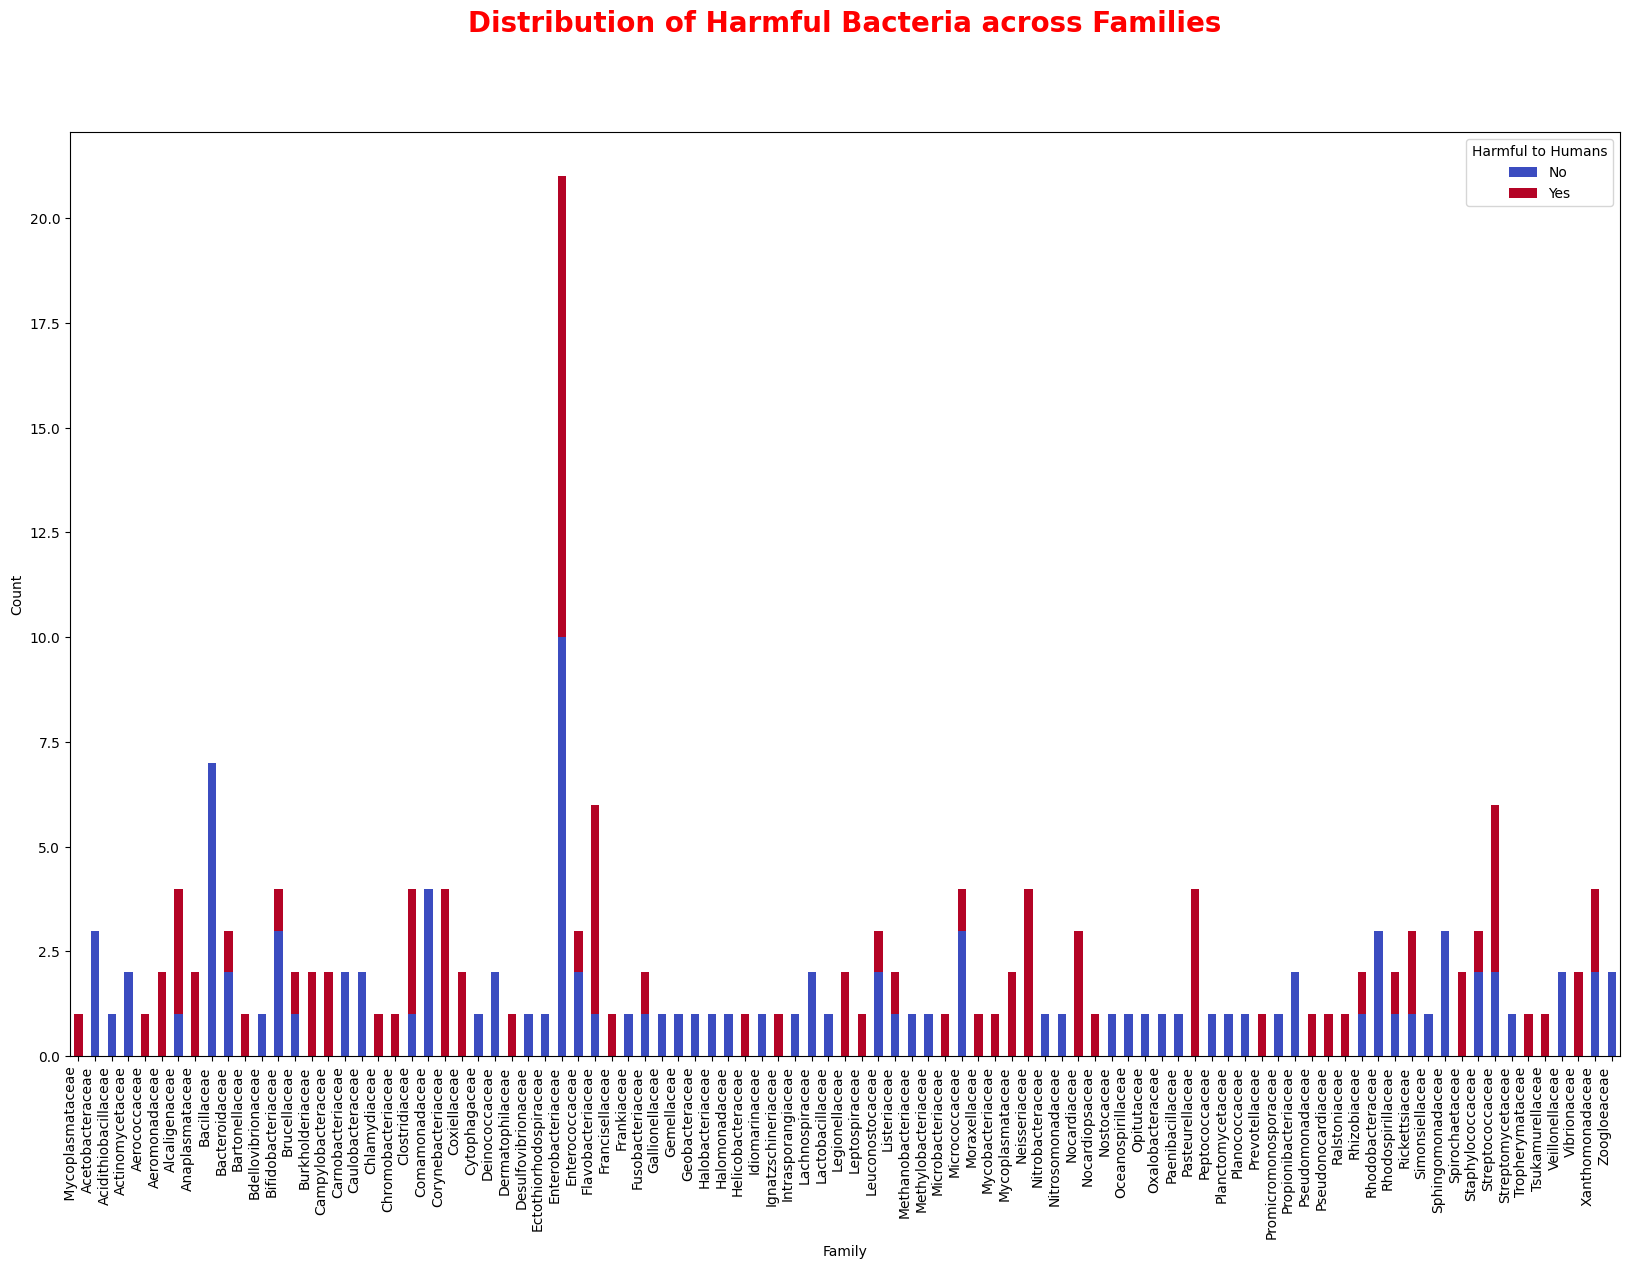

In [14]:
# Create a Stacked Bar Chart

stacked_data = df.groupby(["Family", "Harmful to Humans"]).size().unstack()
stacked_data.plot(kind = "bar", stacked = True, figsize = (20, 12), colormap = "coolwarm")
plt.title("Distribution of Harmful Bacteria across Families", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.xlabel("Family")
plt.ylabel("Count")
plt.xticks(rotation = 90, ha = "right")
plt.legend(title = "Harmful to Humans", loc = "upper right")
plt.show()


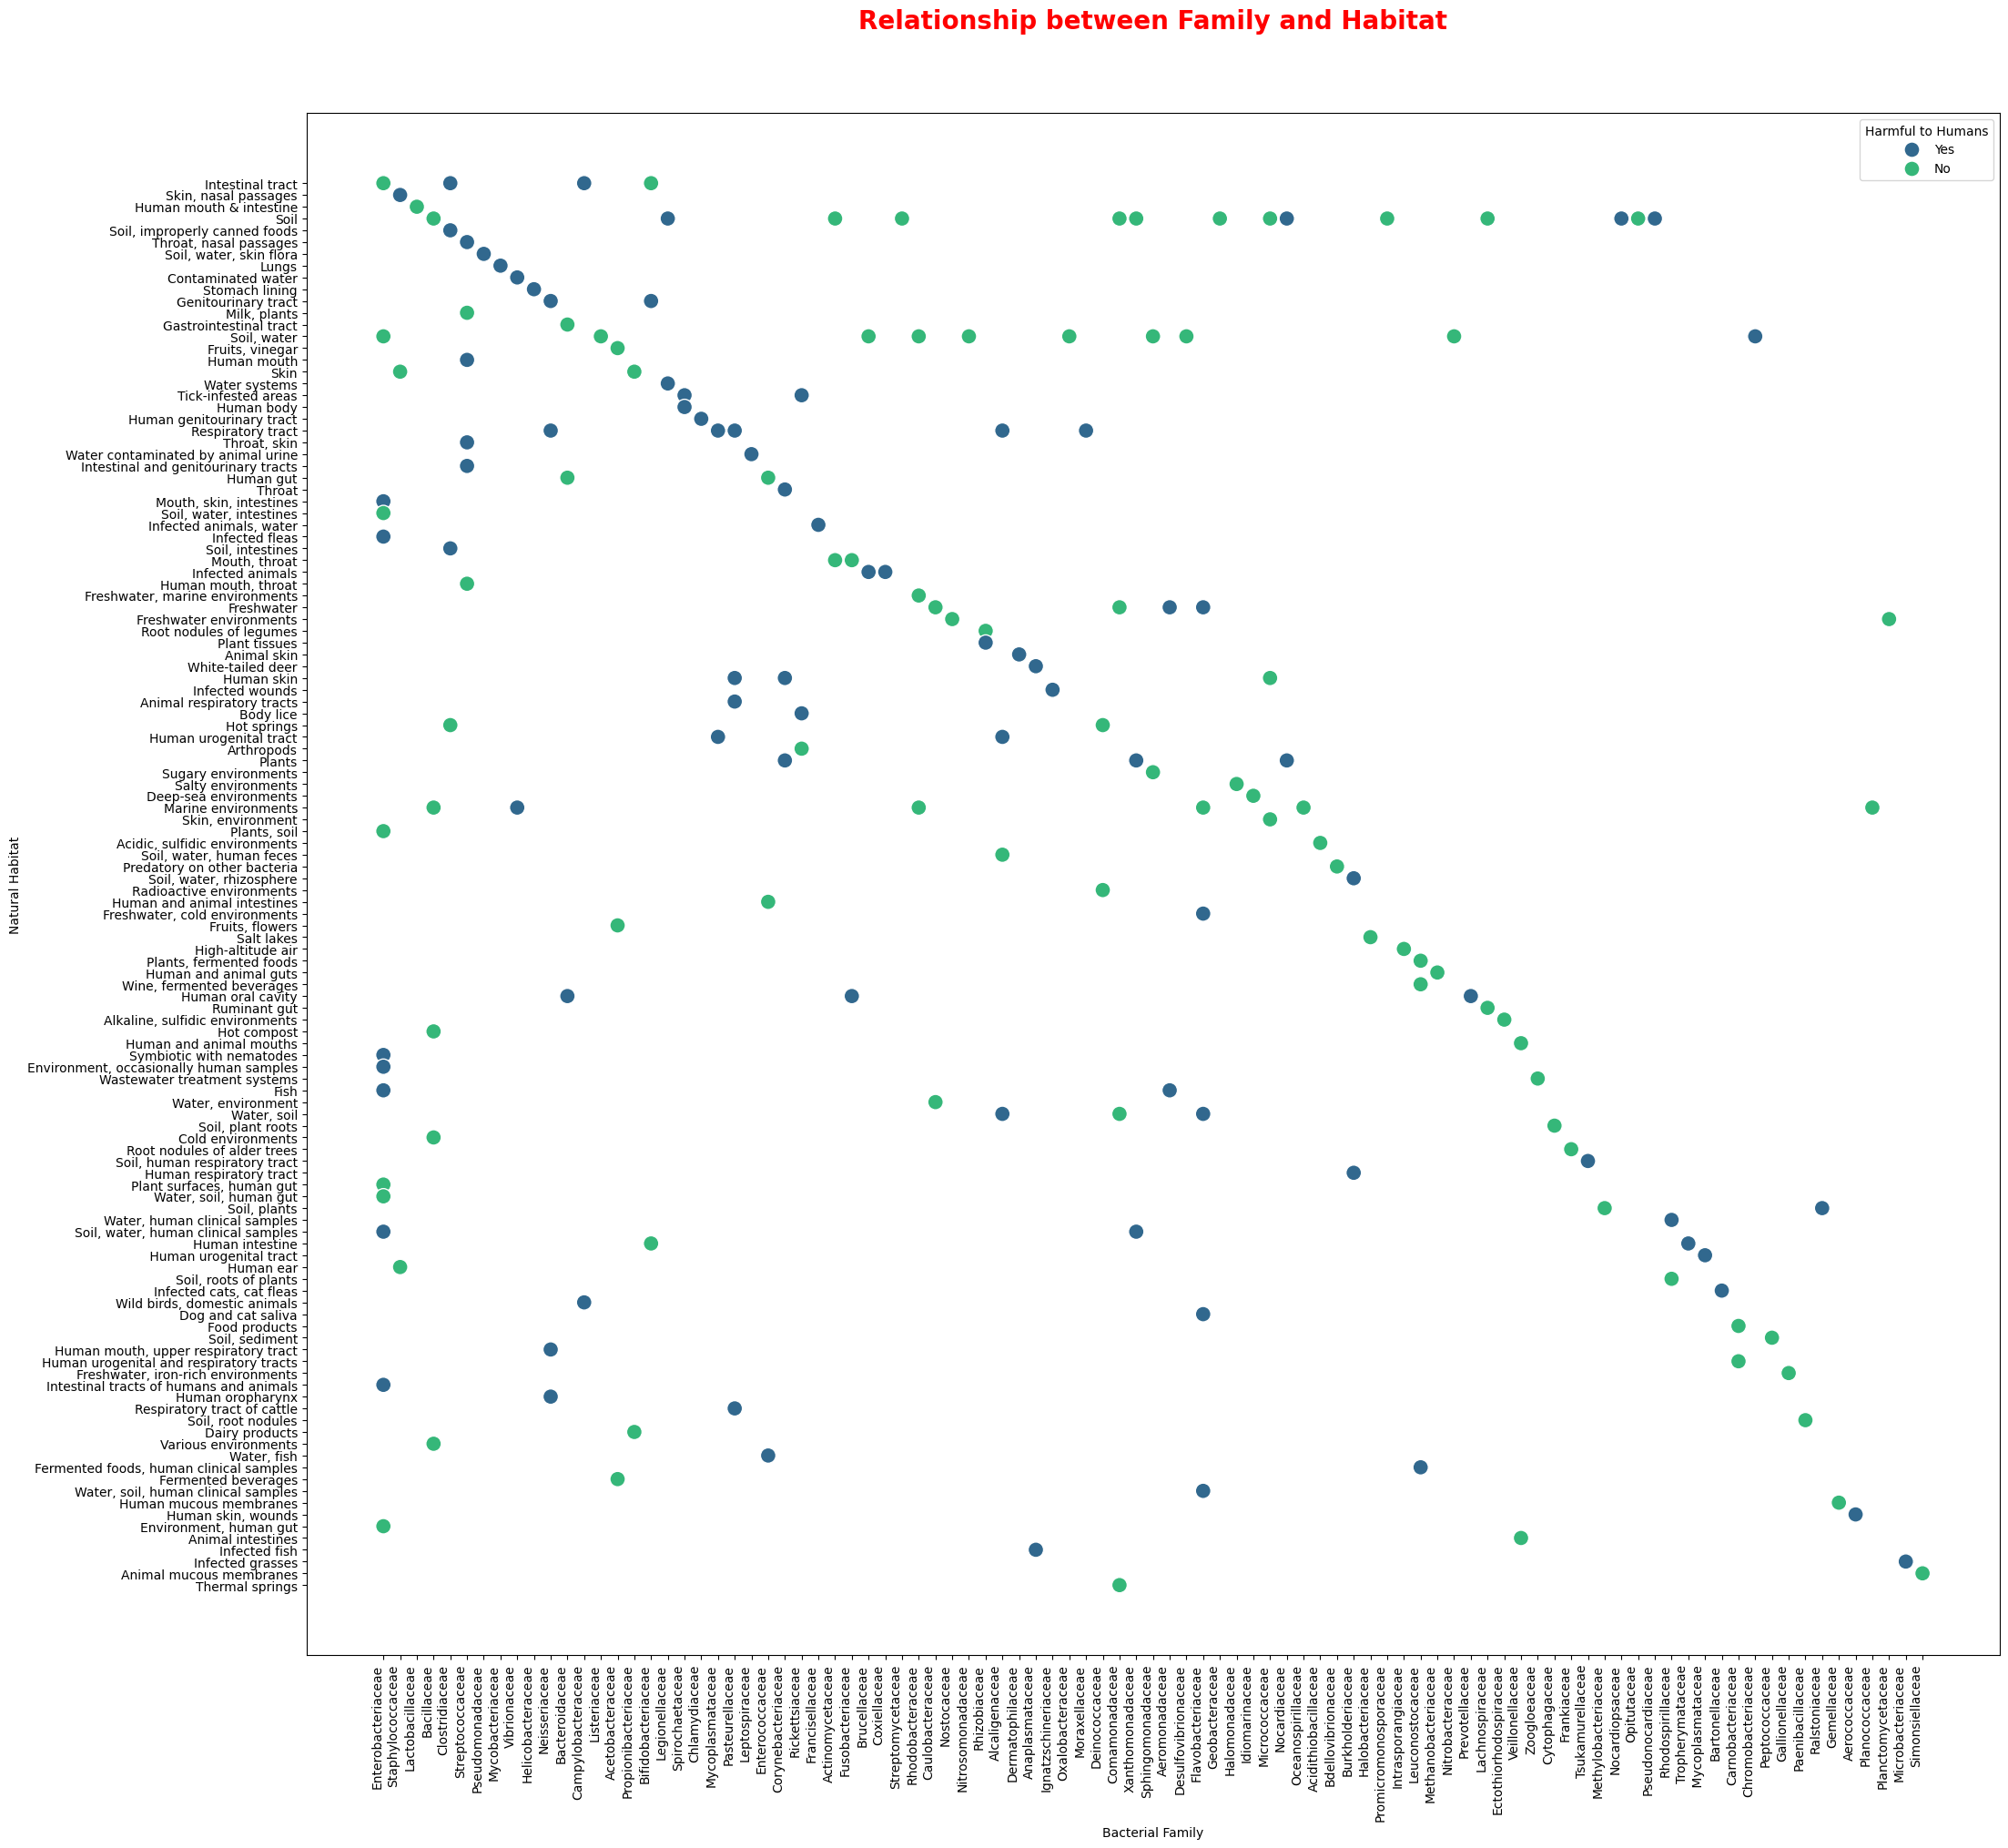

In [15]:
# Create a Scatter PLot

plt.figure(figsize = (24, 22))
sns.scatterplot(x = "Family", y = "Where Found", hue = "Harmful to Humans", data = df, palette = "viridis", s=150, alpha=1)
plt.title("Relationship between Family and Habitat", fontsize = 20, color = "red", fontweight = "bold", y = 1.05)
plt.xlabel("Bacterial Family")
plt.ylabel("Natural Habitat")
plt.xticks(rotation = 90, ha = "right")
plt.legend(title = "Harmful to Humans", loc = "upper right")
plt.show()


In [23]:
# Prepare the data for treemap

treemap_data = df.groupby(["Family", "Where Found"]).size().reset_index(name = "Count")

# PLot the TreeMap

plt.figure(figsize = (36, 30), dpi=400)
squarify.plot(sizes = treemap_data["Count"], label = treemap_data.apply(lambda x: f"{x['Family']} - {x['Where Found']}", axis = 1), alpha = 0.8, text_kwargs = {"fontsize": 8, "fontweight": "bold"}, pad = True)
plt.axis("off")
plt.title("Hierarchical View of Bacterial Families", fontsize = 20, color = "red", fontweight = "bold", y = 1.05)

Text(0.5, 1.05, 'Hierarchical View of Bacterial Families')

In [ ]:
#